In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_csv("Adult Census Income.csv")

In [26]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [27]:
df.shape

(32561, 15)

In [28]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [30]:
X=df.drop('income',axis =1)
y= df[['income']]

In [31]:
X.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States


In [32]:
y.head(10)

,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K
5,<=50K
6,<=50K
7,>50K
8,<=50K
9,>50K


In [33]:
X.replace('?', np.nan, inplace=True)
print(X.isnull().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
dtype: int64


In [34]:
for col in X.columns:
    if X[col].isnull().sum() > 0:
        X[col].fillna(X[col].mode()[0], inplace=True)

X.isnull().sum().sum()

/tmp/ipykernel_3906/965897694.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].mode()[0], inplace=True)


np.int64(0)

In [35]:
X_encoded = pd.get_dummies(X, drop_first=True)

y_encoded = y['income'].apply(lambda x: 1 if '>50K' in x else 0)

print("شكل الميزات بعد التحويل:", X_encoded.shape)
print("عينة من الهدف بعد التحويل:")
print(y_encoded.head())

شكل الميزات بعد التحويل: (32561, 97)
عينة من الهدف بعد التحويل:
0    0
1    0
2    0
3    0
4    0
Name: income, dtype: int64


In [36]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(26048, 97)
(6513, 97)


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("=== Logistic Regression Results ===")
print(f"Accuracy: {acc_lr:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

=== Logistic Regression Results ===
Accuracy: 0.7909

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.93      0.87      4976
           1       0.60      0.34      0.43      1537

    accuracy                           0.79      6513
   macro avg       0.71      0.64      0.65      6513
weighted avg       0.77      0.79      0.77      6513



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [38]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

print("=== K-Nearest Neighbors (KNN) Results ===")
print(f"Accuracy: {acc_knn:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

=== K-Nearest Neighbors (KNN) Results ===
Accuracy: 0.7788

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.93      0.86      4976
           1       0.56      0.30      0.39      1537

    accuracy                           0.78      6513
   macro avg       0.68      0.61      0.63      6513
weighted avg       0.75      0.78      0.75      6513



In [20]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)


y_pred_svm = svm_model.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)

print("=== Support Vector Machine (SVM) Results ===")
print(f"Accuracy: {acc_svm:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

=== Support Vector Machine (SVM) Results ===
Accuracy: 0.7959

Classification Report:
               precision    recall  f1-score   support

           0       0.79      1.00      0.88      4976
           1       0.98      0.14      0.24      1537

    accuracy                           0.80      6513
   macro avg       0.88      0.57      0.56      6513
weighted avg       0.83      0.80      0.73      6513



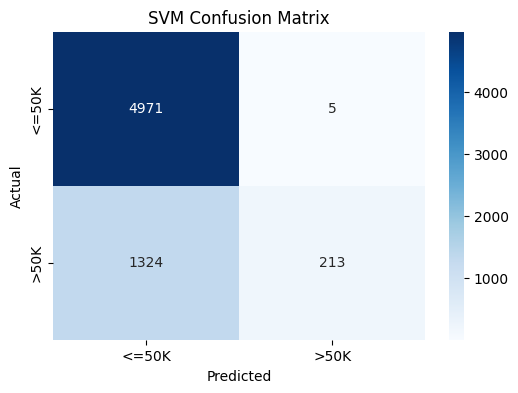

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('SVM Confusion Matrix')
plt.show()

In [22]:
from imblearn.over_sampling import SMOTE
from collections import Counter


print("قبل التوازن:", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("بعد التوازن:", Counter(y_train_balanced))

from sklearn.preprocessing import StandardScaler

scaler_bal = StandardScaler()
X_train_bal_scaled = scaler_bal.fit_transform(X_train_balanced)
X_test_scaled = scaler_bal.transform(X_test)


svm_bal = SVC(kernel='rbf', random_state=42)
svm_bal.fit(X_train_bal_scaled, y_train_balanced)


y_pred_bal = svm_bal.predict(X_test_scaled)

print("=== SVM Results After SMOTE ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_bal):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_bal))

قبل التوازن: Counter({0: 19744, 1: 6304})
بعد التوازن: Counter({0: 19744, 1: 19744})
=== SVM Results After SMOTE ===
Accuracy: 0.8391

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.92      0.90      4976
           1       0.69      0.59      0.63      1537

    accuracy                           0.84      6513
   macro avg       0.78      0.75      0.76      6513
weighted avg       0.83      0.84      0.83      6513



In [39]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nb_model = GaussianNB()

nb_model.fit(X_train_bal_scaled, y_train_balanced)


y_pred_nb = nb_model.predict(X_test_scaled)


print("=== Naive Bayes Results (After SMOTE) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

=== Naive Bayes Results (After SMOTE) ===
Accuracy: 0.5641

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.46      0.62      4976
           1       0.34      0.90      0.49      1537

    accuracy                           0.56      6513
   macro avg       0.64      0.68      0.56      6513
weighted avg       0.79      0.56      0.59      6513

